# `Visualizations + Analysis of IPO Data`

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

In [3]:
price = pd.read_csv(r"C:\Users\Rano's PC\Machine\InsightForge\InsightForge\Avoiding The Hype Trap\_datasets\_engineered_data\prices.csv")


ipo = pd.read_csv(r"C:\Users\Rano's PC\Machine\InsightForge\InsightForge\Avoiding The Hype Trap\_datasets\_engineered_data\ipo.csv")

In [5]:
pd.set_option("display.max_columns",None)

## Univariate Analysis

### IPO

In [6]:
ipo.head()

,company,listing_date,final_price,price_change,retail_subscription,days_since_listing,ret_1w,ret_1m,ret_3m,ret_6m,ret_1y,volatility,max_drawdown,gain_bucket
0,Prince Pipes & Fittings Ltd.,2019-12-30,178,-6.24,1.63,2390,-15.617978,-0.084270,-44.325843,-35.000000,58.511236,3.872215,-60.220704,low
1,Ujjivan Small Finance Bank Ltd.,2019-12-12,37,51.22,45.29,2408,59.729730,41.081081,11.621622,-18.783784,5.000000,3.128991,-59.221658,high
2,CSB Bank Ltd.,2019-12-04,195,53.87,40.98,2416,23.435897,6.692308,-10.435897,-34.820513,15.282051,2.789432,-66.772205,high
3,Vishwaraj Sugar Industries Ltd.,2019-10-15,60,0.58,0.59,2466,-79.850000,-77.866667,-69.950000,-78.333333,-63.283333,4.910541,-37.526205,low
4,Indian Railway Catering & Tourism Corp.Ltd.,2019-10-14,320,127.42,13.28,2467,-51.303125,-41.746875,-42.671875,-21.631250,-16.468750,2.356748,-58.226389,high


In [7]:
ipo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   company               379 non-null    object 
 1   listing_date          379 non-null    object 
 2   final_price           379 non-null    int64  
 3   price_change          379 non-null    float64
 4   retail_subscription   379 non-null    float64
 5   days_since_listing    379 non-null    int64  
 6   ret_1w                377 non-null    float64
 7   ret_1m                378 non-null    float64
 8   ret_3m                378 non-null    float64
 9   ret_6m                378 non-null    float64
 10  ret_1y                302 non-null    float64
 11  volatility            378 non-null    float64
 12  max_drawdown          378 non-null    float64
 13  gain_bucket           379 non-null    object 
dtypes: float64(9), int64(2), object(3)
memory usage: 41.6+ KB


In [8]:
ipo['listing_date'] = pd.to_datetime(ipo['listing_date'])

In [9]:
ipo.describe(include='object').T

,count,unique,top,freq
company,379,379,Indo Farm Equipment Ltd.,1
gain_bucket,379,3,low,173


In [23]:
ipo.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
final_price,379.0,399.865435,337.197625,19.000000,154.000000,306.000000,539.500000,2165.000000
price_change,379.0,22.575541,37.074034,-36.610000,-0.600000,12.050000,32.990000,267.180000
retail_subscription,379.0,22.933087,39.386032,0.020000,2.215000,8.250000,25.095000,360.040000
days_since_listing,379.0,1037.720317,650.467651,198.000000,520.500000,905.000000,1586.000000,2719.000000
ret_1w,377.0,15.436339,45.029245,-96.508021,-6.538462,9.329897,32.015152,259.085714
ret_1m,378.0,15.520305,48.256878,-97.101604,-8.722587,10.137928,37.603209,429.885714
ret_3m,378.0,17.371363,56.863604,-93.486631,-13.708045,11.474517,36.718235,384.062500
ret_6m,378.0,22.562710,71.765916,-93.088670,-20.531139,11.614949,50.293740,504.062500
ret_1y,302.0,36.565548,98.413089,-93.758333,-20.037239,18.209454,60.167732,797.530120
volatility,378.0,3.129795,1.003271,1.214342,2.477072,2.951231,3.736967,7.344325


In [24]:
import random
colors = ['red','green','blue','teal','cyan']


random.choice(colors)

'green'

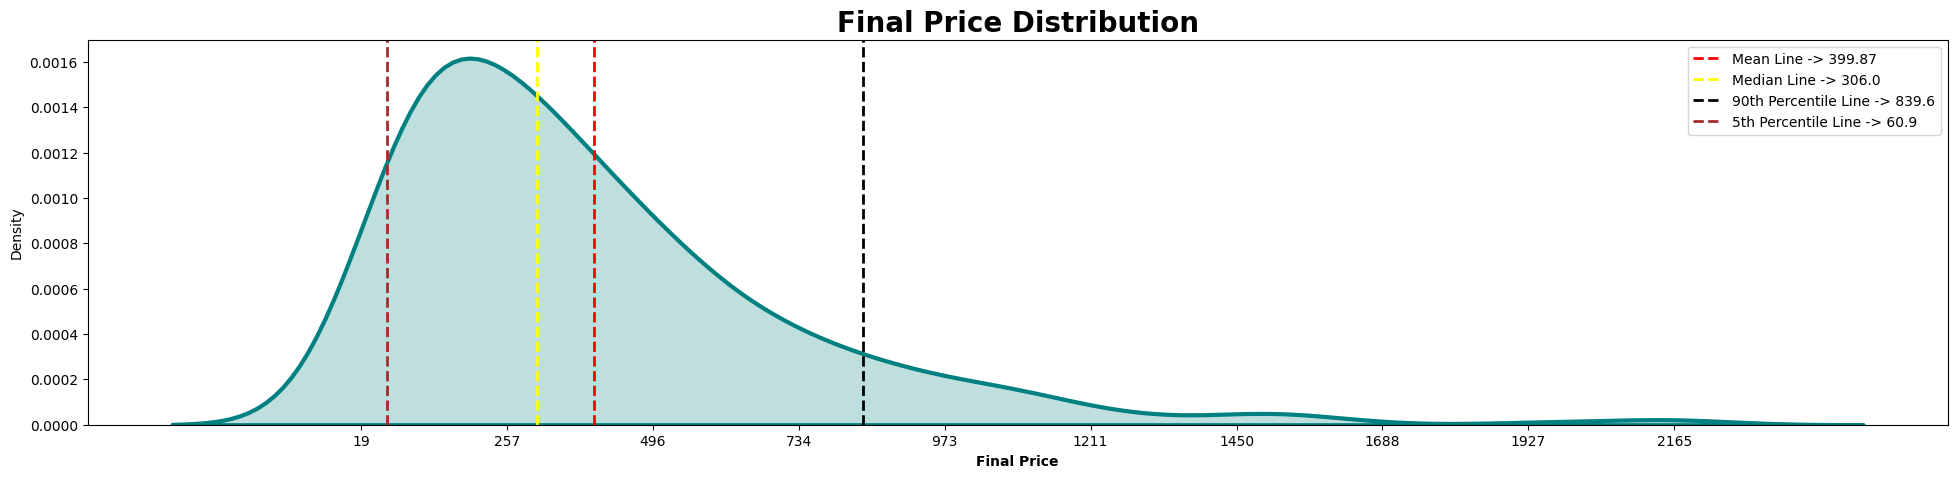

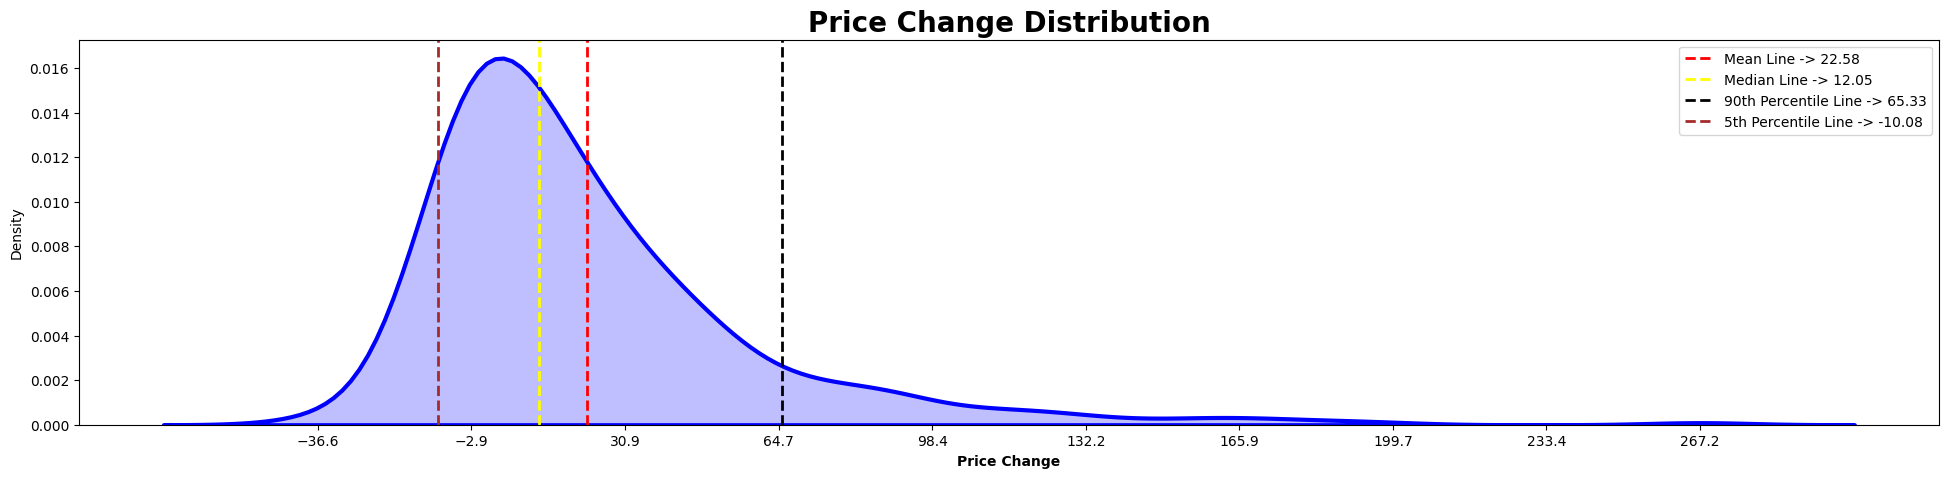

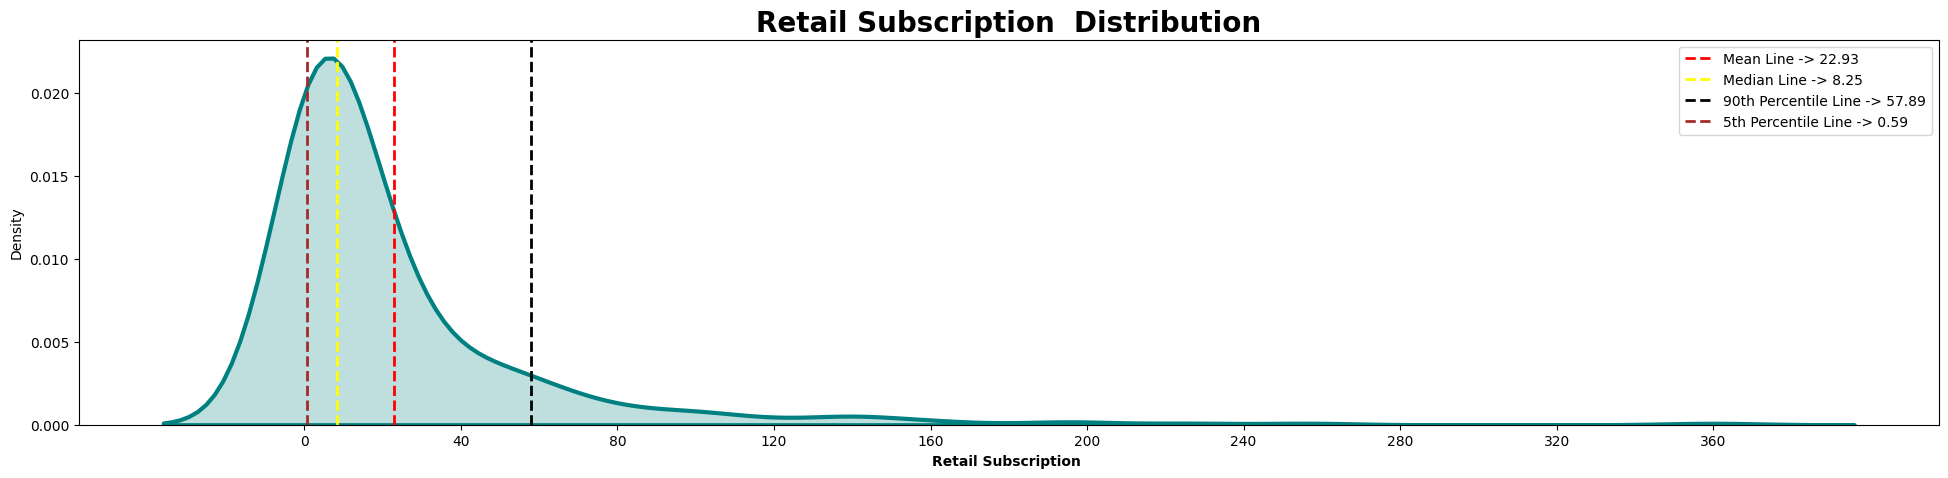

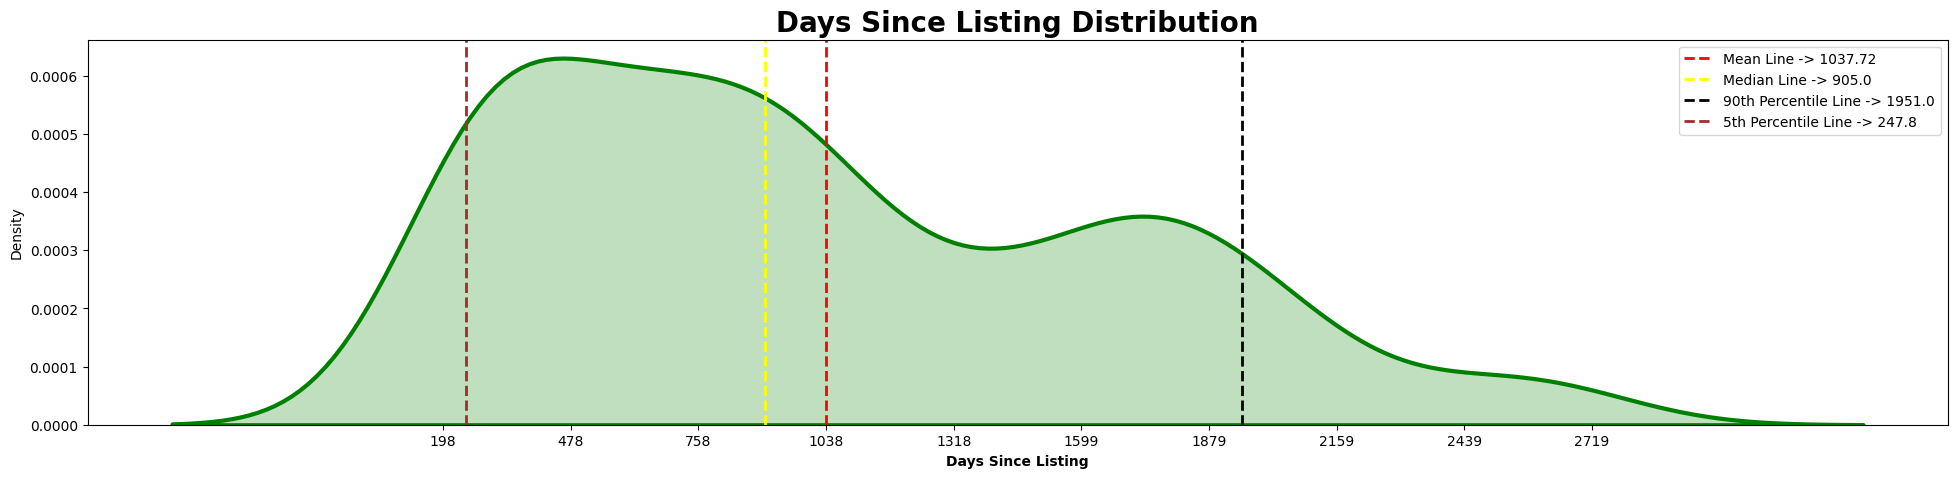

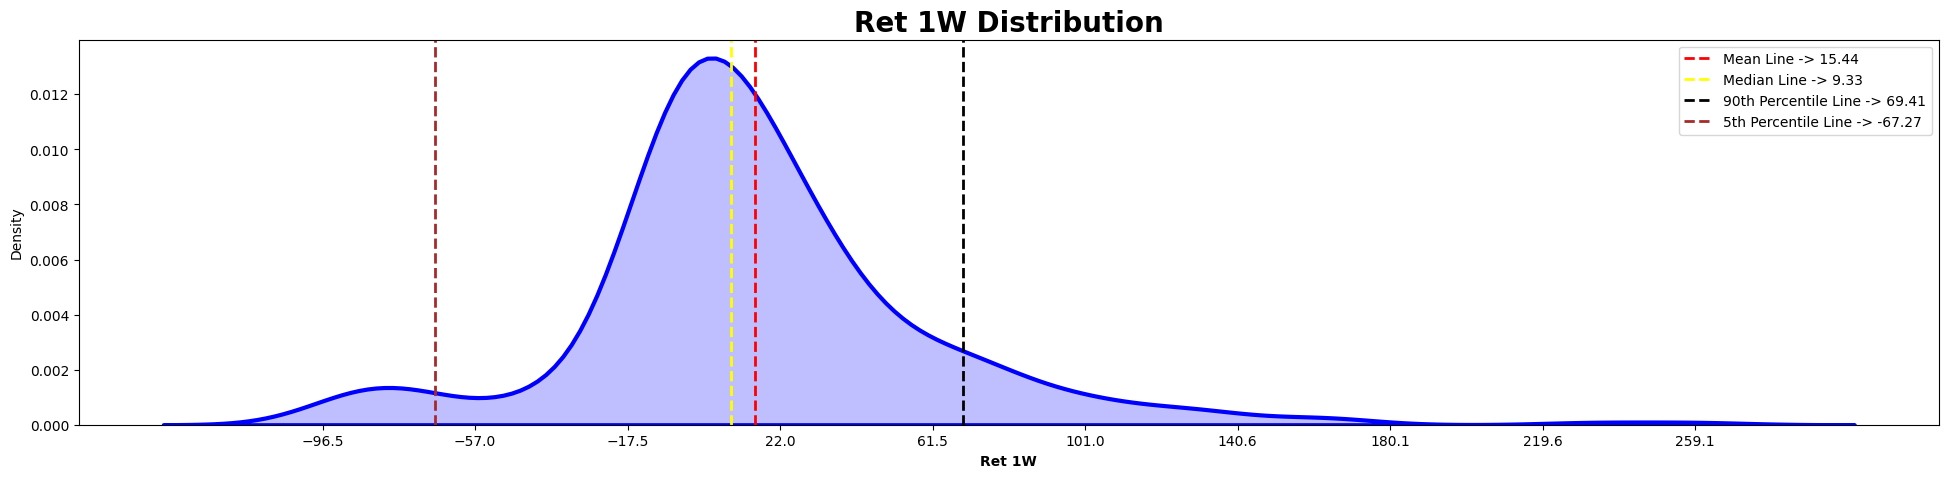

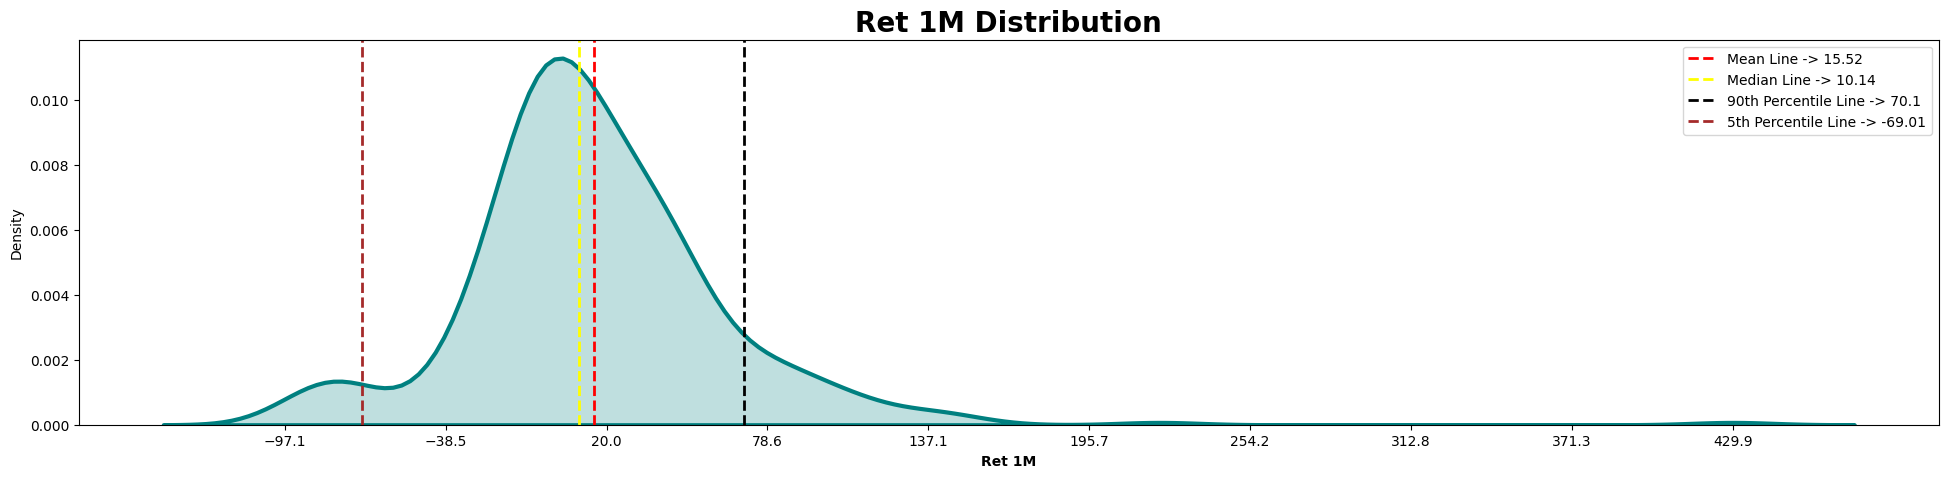

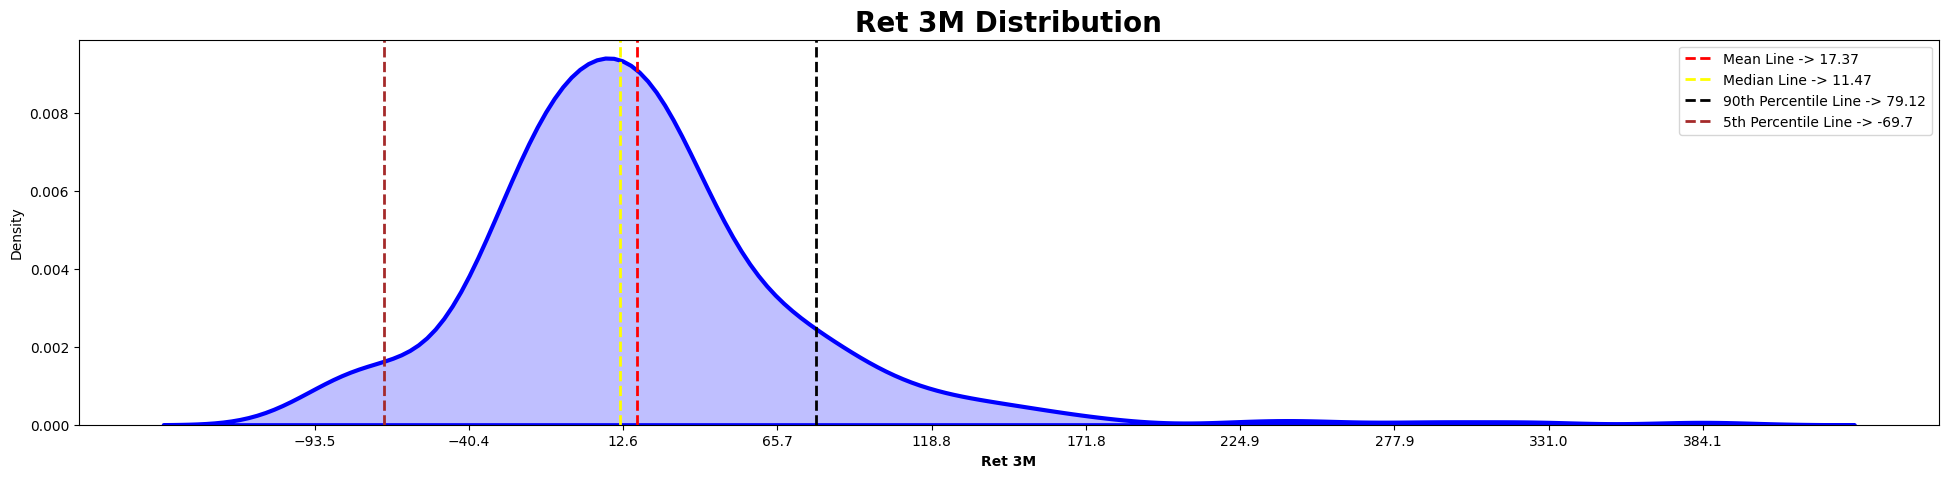

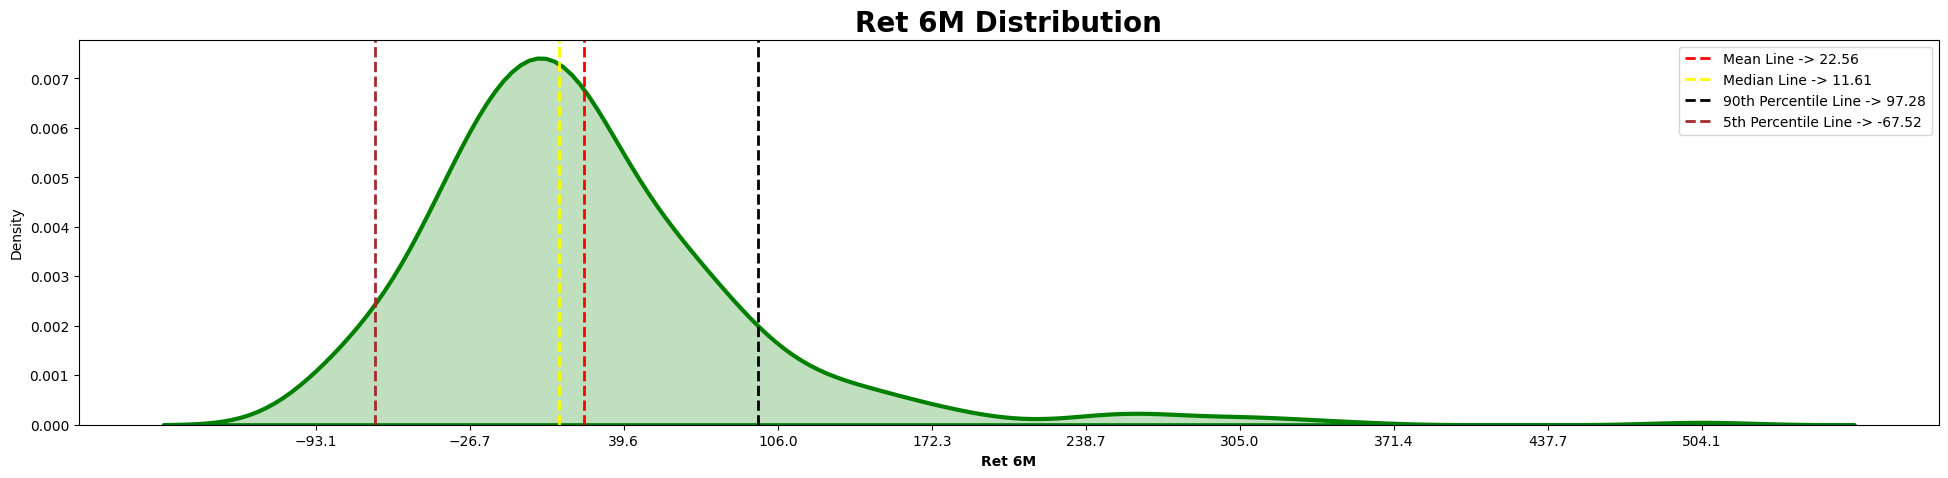

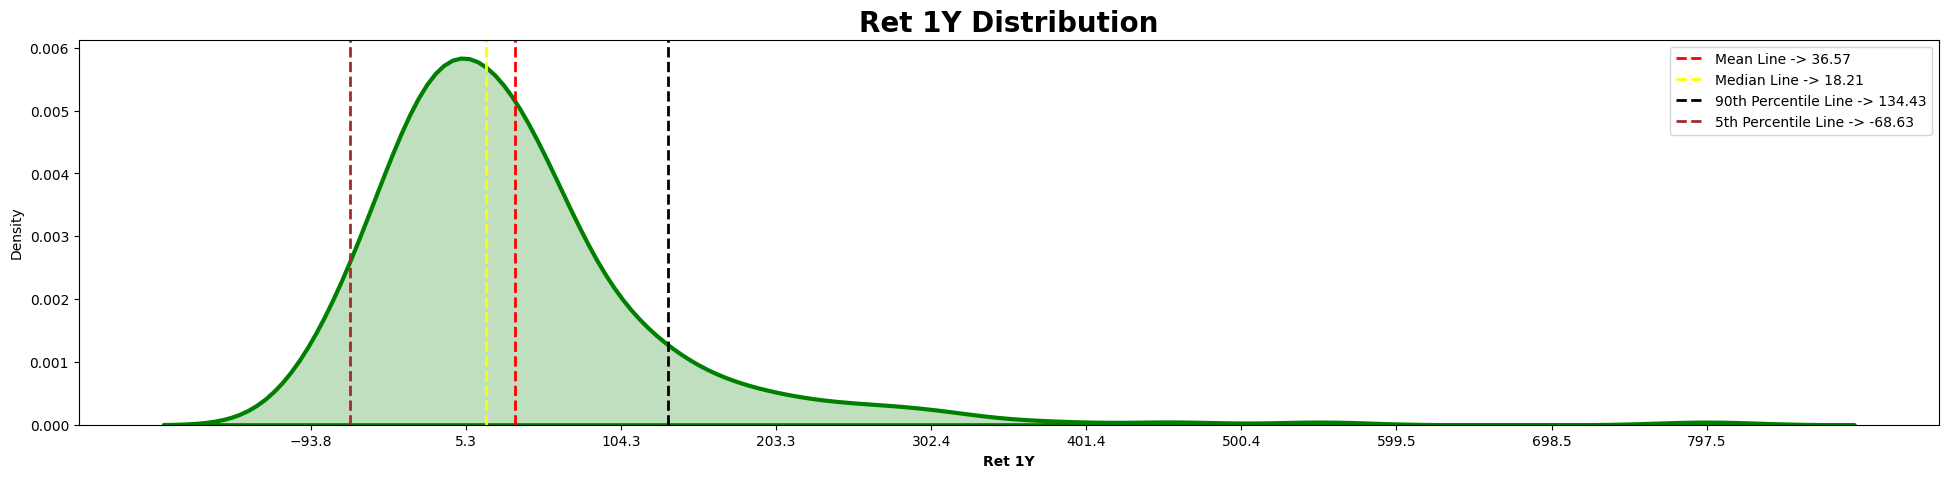

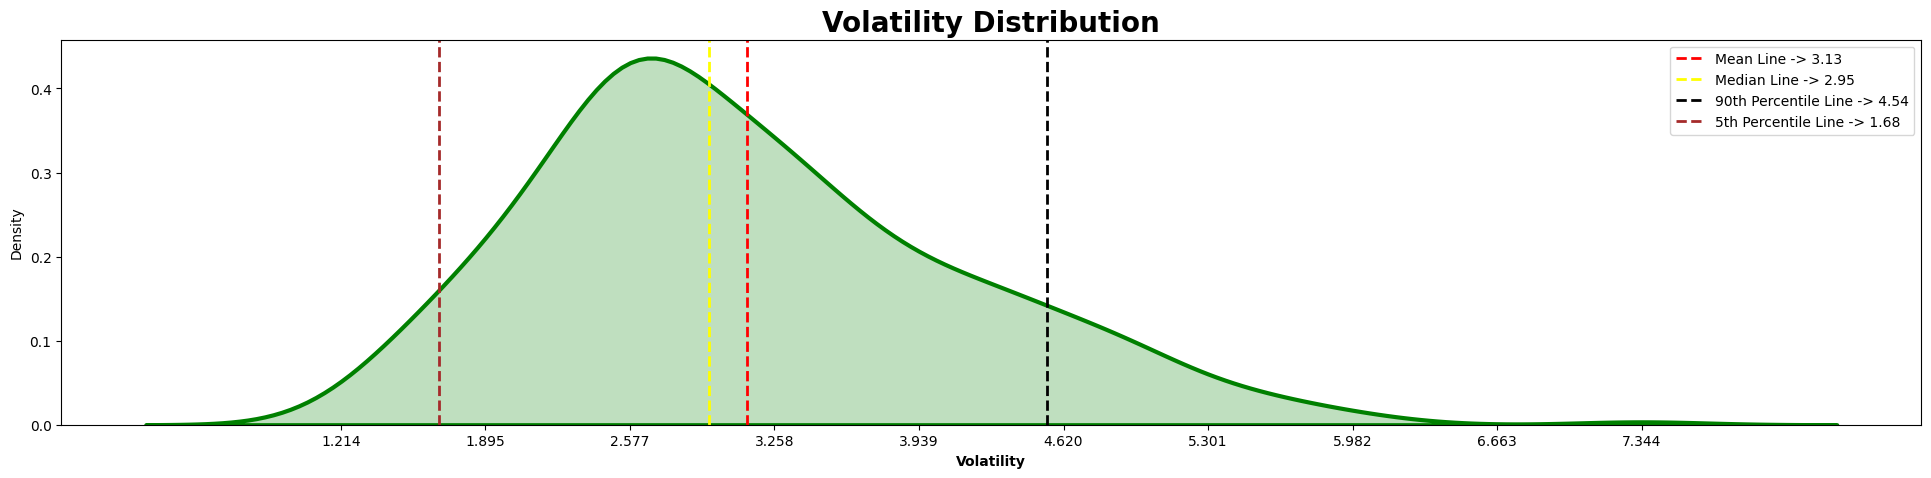

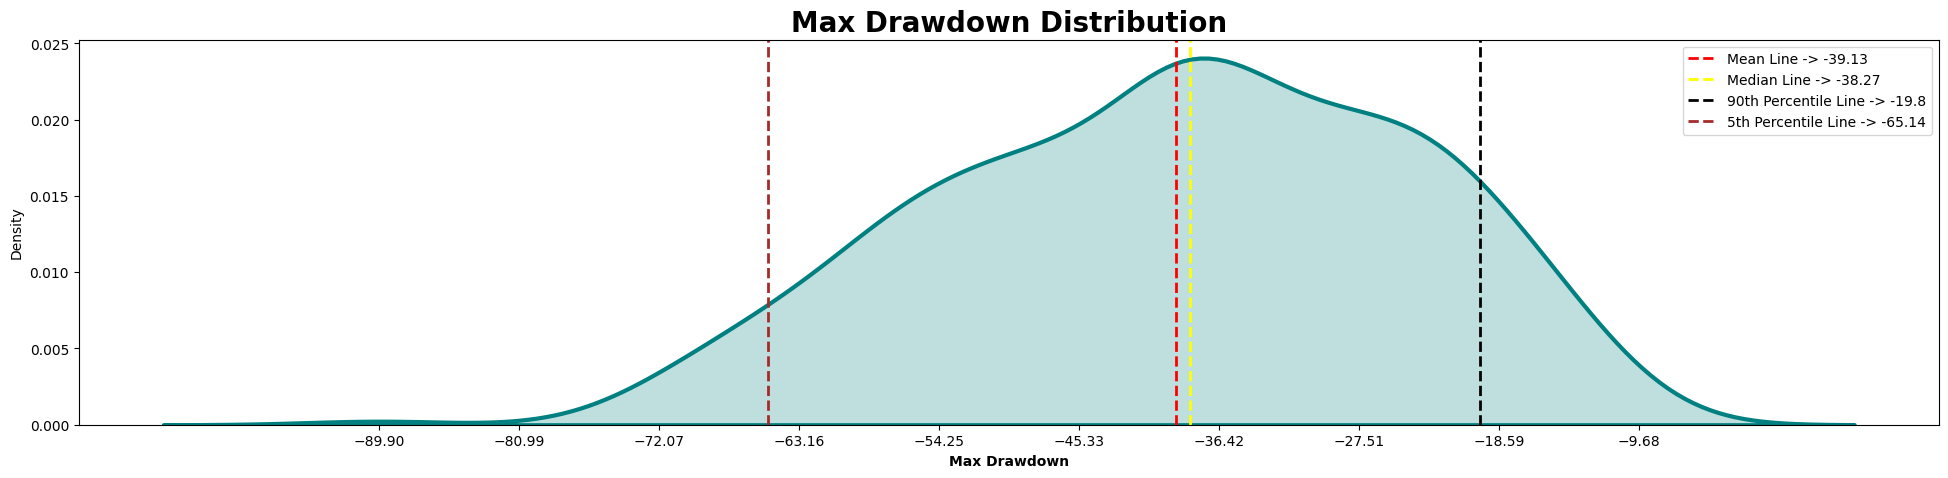

In [45]:
import random
columns = ipo.select_dtypes(['int','float']).columns.tolist()
colors = ['green','blue','teal','cyan']
for column in columns:
    plt.figure(figsize=(24,5))
    sns.kdeplot(x = column, data = ipo, color=random.choice(colors),linewidth = 3, fill=True)
    plt.axvline(ipo[column].mean(),color = 'red',linestyle = '--',linewidth = 2,label = f"Mean Line -> {ipo[column].mean().round(2)}")
    plt.axvline(ipo[column].median(),color = 'yellow',linestyle = '--',linewidth = 2,label = f"Median Line -> {ipo[column].median().round(2)}")
    plt.axvline(ipo[column].quantile(.90),color = 'black',linestyle = '--',linewidth = 2,label = f"90th Percentile Line -> {ipo[column].quantile(.90).round(2)}")
    plt.axvline(ipo[column].quantile(.05),color = 'brown',linestyle = '--',linewidth = 2,label = f"5th Percentile Line -> {ipo[column].quantile(.05).round(2)}")
    plt.grid(alpha = 0)
    plt.legend()
    plt.title(f"{column.title().replace("_"," ")} Distribution",weight = 'bold',fontsize = 20)
    plt.xlabel(f"{column.title().replace("_"," ")}",weight = 'bold')
    plt.xticks(np.linspace(ipo[column].min(),ipo[column].max(),10))
    plt.show()

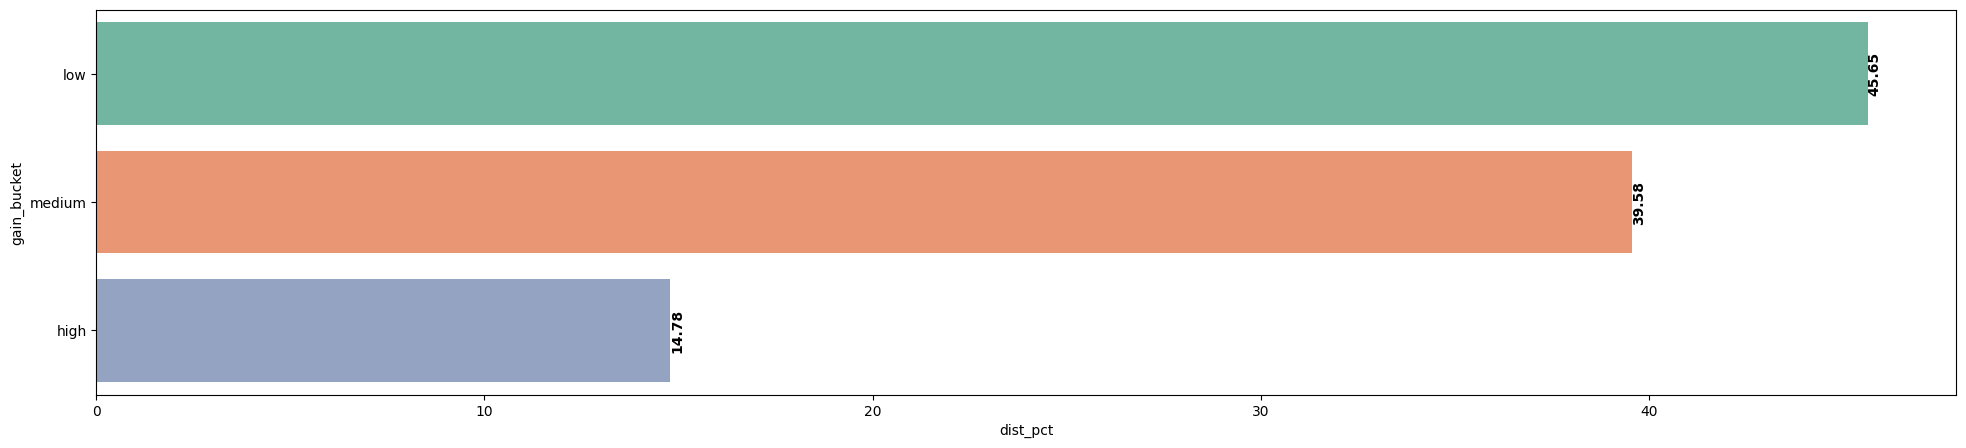

In [49]:
columns = ['gain_bucket']
for column in columns:
    counts = ipo[column].value_counts(normalize=True).mul(100).round(2).reset_index(name = "dist_pct")
    plt.figure(figsize=(24,5))
    ax = sns.barplot( y = column,x = "dist_pct",data = counts,palette='Set2')
    for conatainer in ax.containers:
        ax.bar_label(container=conatainer,rotation = 90,weight = 'bold')
    plt.show()